Iniciando a Análise Climática MENSAL de 4 cidades em ambiente Colab. 📊
Tentando montar o Google Drive...
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Google Drive montado com sucesso.
--- 1. Carregando e Limpando Dados ---
-> Sorocaba: Carregado com 3133 registros válidos.
-> Salto: Carregado com 3005 registros válidos.
-> Cabreuva: Carregado com 2962 registros válidos.
-> Porto Feliz: Carregado com 3125 registros válidos.

--- 2. Calculando Médias Mensais ---

--- Tabela de Médias Mensais Salva (medias_comparativas_mensais_4cidades.csv) ---
Meses comparados no total: 12
| Cidade      |   Temp. Ins. (C) |   Umi. Ins. (%) |
|:------------|-----------------:|----------------:|
| Cabreuva    |          21.7418 |         69.9188 |
| Porto Feliz |          22.4761 |         65.9958 |
| Salto       |          21.1014 |         71.3437 |
| Sorocaba    |          21.3167 |         67.9633 |
| Cabreuva    |     

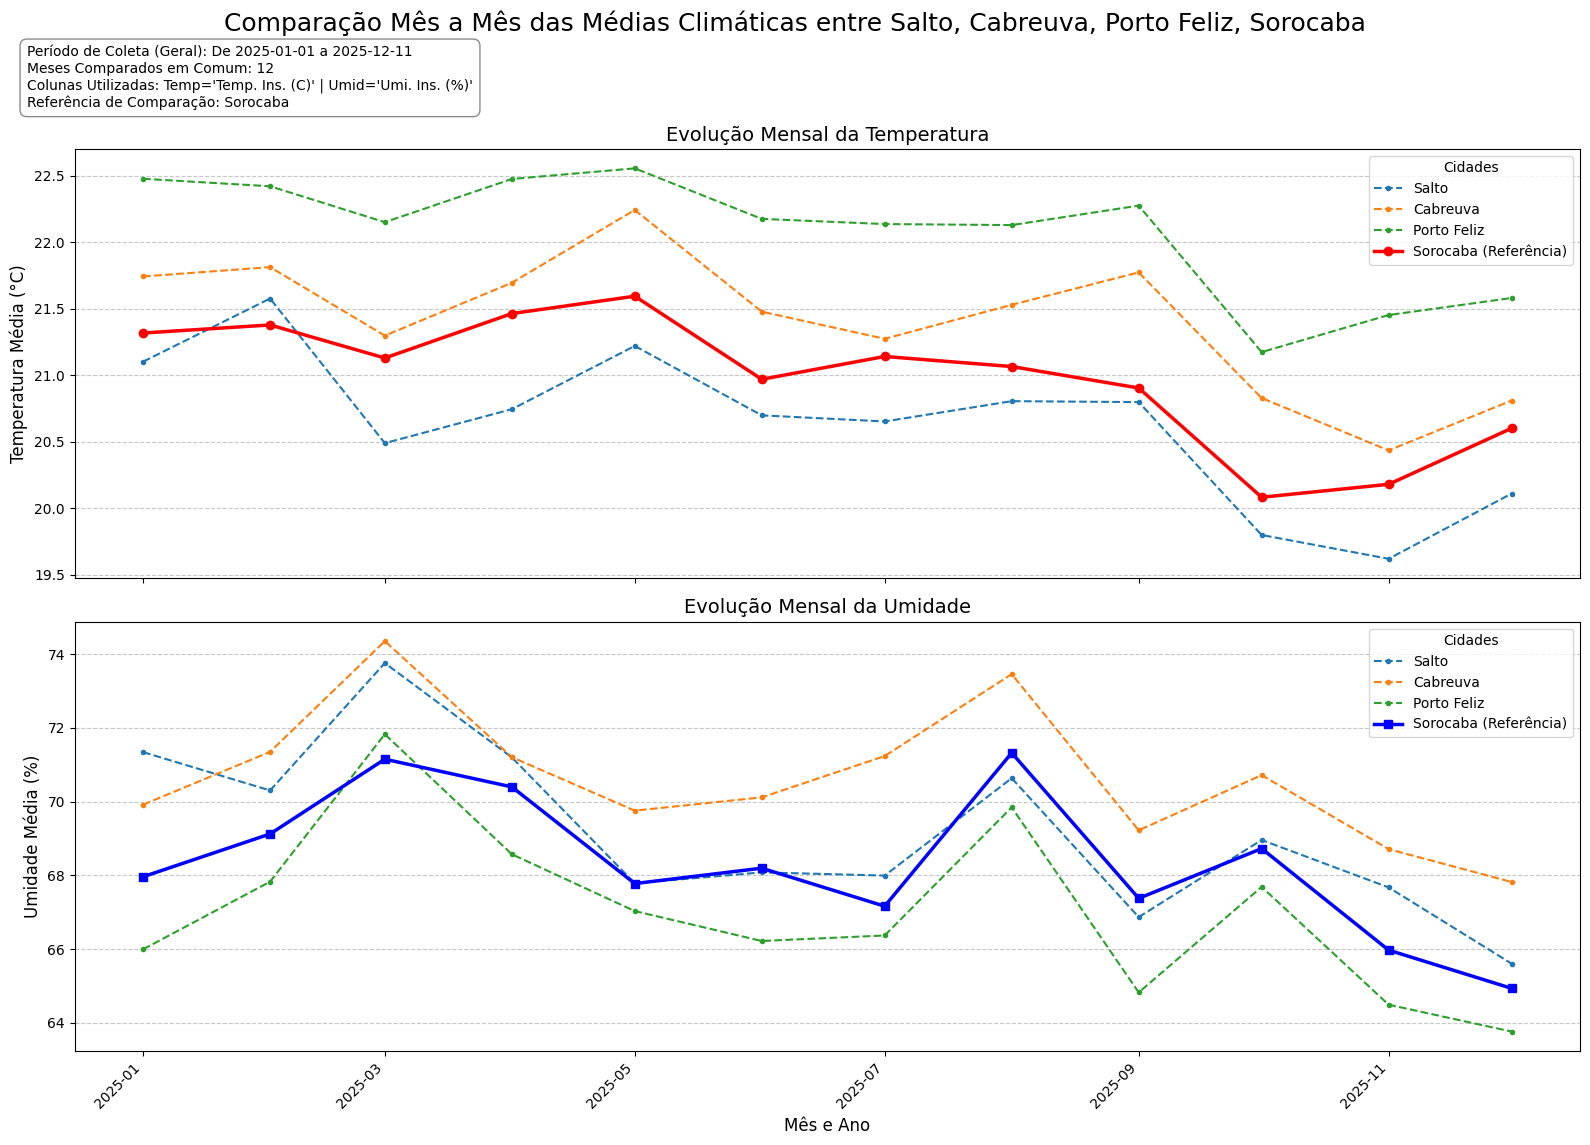


--- 4. Comparação das Médias Anuais ---

 
Médias Anuais Detalhadas (Referência: Sorocaba):
| Cidade      |   Temperatura (°C) |   Umidade (%) |
|:------------|-------------------:|--------------:|
| Cabreuva    |              21.4  |         70.65 |
| Porto Feliz |              22.08 |         67.01 |
| Salto       |              20.62 |         69.13 |
| Sorocaba    |              20.98 |         68.33 |

Referência (Média Anual de Sorocaba):
  Temperatura: 20.98°C
  Umidade: 68.33%

Relatório de Desvio Anual em Relação a Sorocaba:
 - Salto (Distância: 30 km, Direção: Norte (N)):
    Temperatura: Média anual de 20.62°C (Desvio: -0.36°C) -> SEMLHANTE
    Umidade: Média anual de 69.13% (Desvio: +0.80%) -> SEMLHANTE
 - Cabreuva (Distância: 50 km, Direção: Norte (N)):
    Temperatura: Média anual de 21.4°C (Desvio: +0.42°C) -> SEMLHANTE
    Umidade: Média anual de 70.65% (Desvio: +2.32%) -> NÃO SEMELHANTE
 - Porto Feliz (Distância: 40 km, Direção: Oeste (O)):
    Temperatura: Média anua

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from google.colab import drive
import os
import numpy as np

# --- 1. CONFIGURAÇÕES E CAMINHOS PARA MÚLTIPLAS CIDADES ---

# C.1: Configuração das Cidades
CIDADE_REFERENCIA = 'Sorocaba'
CIDADES_ANALISE = ['Salto', 'Cabreuva', 'Porto Feliz']
TODAS_CIDADES = CIDADES_ANALISE + [CIDADE_REFERENCIA]

# Caminho base (AJUSTE ESTE CAMINHO se seus arquivos estiverem em outra pasta!)
CAMINHO_BASE_DRIVE = '/content/drive/MyDrive/Colab Notebooks/Estagio/'

# Dicionário de Arquivos (ASSUMIMOS ESTE PADRÃO DE NOMENCLATURA DE ARQUIVOS)
# * Certifique-se de que estes 4 arquivos existem no seu Google Drive *
ARQUIVOS_CIDADES = {
    'Sorocaba': CAMINHO_BASE_DRIVE + 'Sorocaba.csv',
    'Salto': CAMINHO_BASE_DRIVE + 'Salto.csv',
    'Cabreuva': CAMINHO_BASE_DRIVE + 'Cabreuva.csv',
    'Porto Feliz': CAMINHO_BASE_DRIVE + 'Porto_Feliz.csv',
}

# C.2: NOMES REAIS DAS COLUNAS DE TEMPERATURA E UMIDADE
COLUNA_TEMP = 'Temp. Ins. (C)'
COLUNA_UMID = 'Umi. Ins. (%)'

# C.3: LIMITES DE DESVIO PARA REFERÊNCIA (Mantidos da versão original)
LIMITE_TEMP_DESVIO_C = 1.0
LIMITE_UMID_DESVIO_PCT = 2.0

# C.4: Metadados (Apenas para fins de referência de localização no relatório final)
CIDADES_METADADOS = {
    'Salto': {'distancia': 30, 'direcao': 'Norte (N)'},
    'Cabreuva': {'distancia': 50, 'direcao': 'Norte (N)'},
    'Porto Feliz': {'distancia': 40, 'direcao': 'Oeste (O)'},
    'Sorocaba': {'distancia': 0, 'direcao': 'Referência'},
}

ARQUIVO_SAIDA_MENSAL = 'medias_comparativas_mensais_4cidades.csv'

# --- 2. FUNÇÕES DE ANÁLISE ---

def carregar_e_processar_dados():
    """
    Carrega, limpa e processa dados de todos os 4 arquivos CSV.
    Retorna um único DataFrame longo contendo os dados limpos de todas as cidades.
    """
    df_list = []

    print("--- 1. Carregando e Limpando Dados ---")

    # 3.3. Leitura dos Dados e Limpeza para CADA cidade
    for nome_cidade, caminho_arquivo in ARQUIVOS_CIDADES.items():
        try:
            df = pd.read_csv(caminho_arquivo, sep=';', decimal=',')

            # Adicionar coluna 'Cidade'
            df['Cidade'] = nome_cidade

            # Conversão da coluna de data
            df['Data'] = pd.to_datetime(df['Data'], errors='coerce')

            # Remove registros onde a data ou dados climáticos são inválidos
            df.dropna(subset=['Data', COLUNA_TEMP, COLUNA_UMID], inplace=True)

            df_list.append(df)
            print(f"-> {nome_cidade}: Carregado com {len(df)} registros válidos.")

        except FileNotFoundError:
            print(f"ERRO: Arquivo não encontrado para {nome_cidade}. Verifique o caminho: {caminho_arquivo}")
            continue
        except KeyError as e:
            print(f"ERRO: Coluna {e} faltando em {nome_cidade}.")
            continue

    if not df_list:
        raise Exception("Nenhum arquivo CSV foi carregado com sucesso. Verifique os caminhos e arquivos.")

    # Concatena todos os DataFrames em um único
    df_todos_dados = pd.concat(df_list, ignore_index=True)

    # Cálculo do Período de Coleta GERAL (Apenas para o relatório)
    data_inicio = df_todos_dados['Data'].min().strftime('%Y-%m-%d')
    data_fim = df_todos_dados['Data'].max().strftime('%Y-%m-%d')
    periodo_coleta = f"De {data_inicio} a {data_fim}"

    return df_todos_dados, periodo_coleta

def calcular_medias_mensais(df_todos_dados):
    """
    Calcula as médias aritméticas mensais de Temperatura e Umidade para todas as cidades.
    """
    print("\n--- 2. Calculando Médias Mensais ---")

    # Cria a coluna de Mês/Ano (para agrupar)
    df_todos_dados['Mes_Ano'] = df_todos_dados['Data'].dt.to_period('M')

    # Cálculo das Médias Mensais para TODAS as cidades
    df_medias = df_todos_dados.groupby(['Cidade', 'Mes_Ano'])[[COLUNA_TEMP, COLUNA_UMID]].mean().reset_index()

    # Cria a coluna de Data para plotagem
    df_medias['Data_Plot'] = df_medias['Mes_Ano'].dt.to_timestamp()

    # Reordena o DataFrame para facilitar a plotagem cronológica
    df_medias = df_medias.sort_values(['Data_Plot', 'Cidade']).reset_index(drop=True)

    return df_medias

def gerar_grafico_mensal(df_mensal, periodo_coleta):
    """
    Gera dois gráficos de linha, comparando TºC e Umidade mensais das 4 cidades.
    """

    # Pega o período comum de plotagem
    meses_comuns = df_mensal['Mes_Ano'].nunique()

    print(f"\n--- 3. Gerando Gráficos de Linha ({meses_comuns} meses comuns) ---")

    # --- Configuração da Figure com 2 Subplots (Temperatura e Umidade) ---
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 12), sharex=True)
    fig.suptitle(f'Comparação Mês a Mês das Médias Climáticas entre {", ".join(TODAS_CIDADES)}', fontsize=18, y=0.95)

    # --- Gráfico 1: Temperatura ---
    for cidade in TODAS_CIDADES:
        df_cidade = df_mensal[df_mensal['Cidade'] == cidade]

        # Destaca Sorocaba com uma linha mais grossa e de cor de referência
        if cidade == CIDADE_REFERENCIA:
            ax1.plot(df_cidade['Data_Plot'], df_cidade[COLUNA_TEMP],
                     marker='o', linestyle='-', color='red', linewidth=2.5, label=f'{cidade} (Referência)')
        else:
            ax1.plot(df_cidade['Data_Plot'], df_cidade[COLUNA_TEMP],
                     marker='.', linestyle='--', label=f'{cidade}')

    ax1.set_ylabel('Temperatura Média (°C)', fontsize=12)
    ax1.set_title('Evolução Mensal da Temperatura', fontsize=14)
    ax1.grid(axis='y', linestyle='--', alpha=0.7)
    ax1.legend(title='Cidades', loc='upper right')

    # --- Gráfico 2: Umidade ---
    for cidade in TODAS_CIDADES:
        df_cidade = df_mensal[df_mensal['Cidade'] == cidade]

        # Destaca Sorocaba com uma linha mais grossa e de cor de referência
        if cidade == CIDADE_REFERENCIA:
            ax2.plot(df_cidade['Data_Plot'], df_cidade[COLUNA_UMID],
                     marker='s', linestyle='-', color='blue', linewidth=2.5, label=f'{cidade} (Referência)')
        else:
            ax2.plot(df_cidade['Data_Plot'], df_cidade[COLUNA_UMID],
                     marker='.', linestyle='--', label=f'{cidade}')

    ax2.set_xlabel('Mês e Ano', fontsize=12)
    ax2.set_ylabel('Umidade Média (%)', fontsize=12)
    ax2.set_title('Evolução Mensal da Umidade', fontsize=14)
    ax2.grid(axis='y', linestyle='--', alpha=0.7)
    ax2.legend(title='Cidades', loc='upper right')

    # --- Formatação do Eixo X (Comum aos dois gráficos) ---
    ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    plt.xticks(rotation=45, ha='right')

    # --- Metadados (Caixa de Texto Geral) ---
    texto_metadados = (
        f"Período de Coleta (Geral): {periodo_coleta}\n"
        f"Meses Comparados em Comum: {meses_comuns}\n"
        f"Colunas Utilizadas: Temp='{COLUNA_TEMP}' | Umid='{COLUNA_UMID}'\n"
        f"Referência de Comparação: {CIDADE_REFERENCIA}"
    )

    # Adiciona a caixa de texto no canto superior esquerdo da figura
    fig.text(0.02, 0.92, texto_metadados, transform=fig.transFigure,
             fontsize=10, verticalalignment='top', horizontalalignment='left',
             bbox=dict(boxstyle="round,pad=0.5", fc="white", alpha=0.9, ec="gray", lw=1))

    plt.tight_layout(rect=[0, 0, 1, 0.9])
    plt.show()

def comparar_medias_anuais(df_todos_dados):
    """
    Calcula a média anual (geral) e compara Salto, Cabreúva e Porto Feliz com Sorocaba.
    """
    print("\n--- 4. Comparação das Médias Anuais ---")

    # Calcular as médias anuais (média de todas as medições válidas)
    medias_anuais = df_todos_dados.groupby('Cidade').agg({
        COLUNA_TEMP: 'mean',
        COLUNA_UMID: 'mean'
    }).rename(columns={COLUNA_TEMP: 'Temperatura (°C)', COLUNA_UMID: 'Umidade (%)'}).round(2)

    print("\n ")

    print("Médias Anuais Detalhadas (Referência: Sorocaba):")
    print(medias_anuais.to_markdown())

    # Valores de referência de Sorocaba
    temp_sorocaba = medias_anuais.loc[CIDADE_REFERENCIA, 'Temperatura (°C)']
    humid_sorocaba = medias_anuais.loc[CIDADE_REFERENCIA, 'Umidade (%)']

    print(f"\nReferência (Média Anual de {CIDADE_REFERENCIA}):")
    print(f"  Temperatura: {temp_sorocaba}°C")
    print(f"  Umidade: {humid_sorocaba}%")

    print("\nRelatório de Desvio Anual em Relação a Sorocaba:")
    for cidade in CIDADES_ANALISE:
        temp_cidade = medias_anuais.loc[cidade, 'Temperatura (°C)']
        humid_cidade = medias_anuais.loc[cidade, 'Umidade (%)']

        diff_temp = round(temp_cidade - temp_sorocaba, 2)
        diff_humid = round(humid_cidade - humid_sorocaba, 2)

        # Análise de Temperatura
        if abs(diff_temp) > LIMITE_TEMP_DESVIO_C:
            temp_status = "NÃO SEMELHANTE"
        else:
            temp_status = "SEMLHANTE"

        # Análise de Umidade
        if abs(diff_humid) > LIMITE_UMID_DESVIO_PCT:
            humid_status = "NÃO SEMELHANTE"
        else:
            humid_status = "SEMLHANTE"

        print(f" - {cidade} (Distância: {CIDADES_METADADOS[cidade]['distancia']} km, Direção: {CIDADES_METADADOS[cidade]['direcao']}):")
        print(f"    Temperatura: Média anual de {temp_cidade}°C (Desvio: {diff_temp:+.2f}°C) -> {temp_status}")
        print(f"    Umidade: Média anual de {humid_cidade}% (Desvio: {diff_humid:+.2f}%) -> {humid_status}")


def main():
    """Função principal para executar o programa em ambiente Colab."""

    print("Iniciando a Análise Climática MENSAL de 4 cidades em ambiente Colab. 📊")

    # 3.1. Montagem do Google Drive
    try:
        print("Tentando montar o Google Drive...")
        drive.mount('/content/drive')
        print("Google Drive montado com sucesso.")
    except Exception as e:
        print(f"ERRO ao montar o Drive: {e}. Verifique se está no Google Colab.")
        return

    try:
        # 3.2. Carregar e Limpar Dados de Todas as Cidades
        df_todos_dados, periodo_coleta = carregar_e_processar_dados()

        if df_todos_dados.empty:
            print("\nERRO: Não há dados válidos para prosseguir com a análise.")
            return

        # 3.3. Cálculo das Médias Mensais
        df_mensal = calcular_medias_mensais(df_todos_dados)

        # 3.4. Salvamento da Tabela de Médias Mensais
        df_saida_final = df_mensal.drop(columns=['Data_Plot', 'Mes_Ano'])
        df_saida_final.rename(columns={COLUNA_TEMP: 'Temp_Media', COLUNA_UMID: 'Umid_Media'}).to_csv(ARQUIVO_SAIDA_MENSAL, index=False)

        print(f"\n--- Tabela de Médias Mensais Salva ({ARQUIVO_SAIDA_MENSAL}) ---")
        print(f"Meses comparados no total: {df_mensal['Mes_Ano'].nunique()}")
        print(df_saida_final.head().to_markdown(index=False))
        print("...\n")

        # 3.5. Geração dos Gráficos Mensais
        gerar_grafico_mensal(df_mensal, periodo_coleta)

        # 3.6. Comparação das Médias Anuais
        comparar_medias_anuais(df_todos_dados)

        print("\nAnálise multi-cidades concluída com sucesso.")

    except Exception as e:
        print(f"\nOcorreu um erro inesperado no fluxo principal: {e}")
        # Se for um erro no Colab, o stack trace será útil.
        import traceback
        traceback.print_exc()


if __name__ == '__main__':
    main()